# Lecture 13

## Transformers for antibody binding prediction

So far, we have mostly modeled structured predictors:

- tabular data, where each row has the same columns
- image data, where each image is an array of pixels

Deep learning is powerful because it lets us learn useful representations of much less structured data. Text, biological sequences, and many biomedical records cannot be represented as tabular data.

Today we keep the familiar supervised learning setup,

$$
(X_i, y_i), \quad i = 1, \ldots, n,
$$

but make $X_i$ more flexible: an antibody amino-acid sequence. The outcome $y_i$ is whether the antibody binds an IL-6 antigen.

Antibodies are proteins made by the immune system that can recognize specific molecular targets, called antigens. Predicting whether an antibody recognizes ("binds") an antigen is helpful for the development of diagnostics and therapeutics, as well as understanding immune responses. For example, for COVID-19, antibody binding was used both in monoclonal antibody treatments that bound the SARS-CoV-2 spike protein and in rapid antigen tests where lab-made antibodies were used to check for the existence of viral proteins in a test sample.

## Why deep learning here?

Classical models usually need us to turn an object into fixed features first. For an antibody sequence, we could count amino acids or use hand-engineered features, but that throws away a lot of structure.

A neural network can learn the features it needs from the raw sequence:

```text
amino-acid sequence -> learned representation -> prediction
```

The transformer is a flexible architecture for this because it can update each position using information from other positions in the sequence.

In [1]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

np.random.seed(2026)
torch.manual_seed(2026)
random.seed(2026)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


## Representing sequences with embeddings

Amino acid sequences are strings, but neural networks need numbers.

We will refer to each amino acid as a token. In LLM settings, tokens are often words or sub-words. 

The set of all unique tokens is called the "vocabulary." In this case, the vocabulary is just the 20 unique amino acids, plus an additional special token we describe later. In LLM settings, the vocabulary is much larger since there are so many words/sub-words in any language. 

Each unique token is first mapped to an integer index. Then the model uses an embedding table to map each token index to a learned vector.

For example:

```text
A -> 0 -> [0.12, -0.03, 0.44, ...]
C -> 1 -> [-0.20, 0.51, 0.08, ...]
```

## Attention: updating representations using context

Attention updates each token embedding using context from other tokens.

For each token embedding, the model creates three vectors:

- **Query**: what am I looking for?
- **Key**: what kind of information do I have?
- **Value**: what information should I pass along?

For intuition, imagine the phrase `red blood cell`. One attention head might learn an adjective-to-noun pattern: when the current token is a noun, look backward for adjectives.

In that head, the token `cell` might have a query that asks, "are there descriptive words before me?" The token `red` might have a key that says, "I am a color/adjective-like modifier." If those vectors line up, the dot product between the query for `cell` and the key for `red` will be large.

Let $X$ be the matrix of token embeddings, where each row is one token. The query, key, and value matrices are learned linear transformations:

$$
Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V.
$$

Self-attention is usually written as

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V.
$$

Here, $d$ is the dimension of the key/query vectors. The matrix $QK^T$ contains dot products. Softmax turns scores into weights. Multiplying by $V$ takes weighted averages of the value vectors.

In simplified notation, one attention layer updates the token representations as

$$
X_{\text{new}} = X + \text{Attention}(Q, K, V).
$$

For an antibody sequence, this means one amino-acid position can update its representation using information from other positions.

## Biomedical example: antibody binding prediction

Now we use attention for a supervised biomedical problem.

Input $X_i$: a VHH antibody amino-acid sequence  
Outcome $y_i$: binding vs. non-binding to IL-6

We will use AVIDa-hIL6, a public VHH antibody-antigen interaction dataset. For lecture speed, we only load a subset.

In [ ]:
AVIDA_URL = "https://huggingface.co/datasets/COGNANO/AVIDa-hIL6/resolve/main/AVIDa-hIL6.csv"

df = pd.read_csv(
    AVIDA_URL,
    usecols=["VHH_sequence", "label", "Ag_label"],
    nrows=1000
)

(100, 3)
label
0    97
1     3
Name: count, dtype: int64
label
0    0.97
1    0.03
Name: proportion, dtype: float64


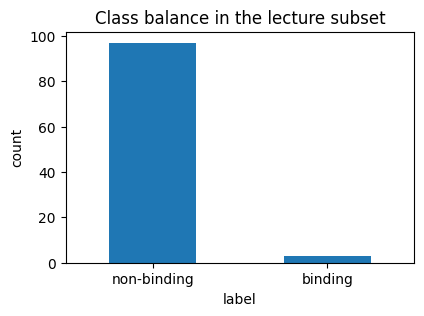

In [3]:
print(df.shape)
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).rename("proportion"))

plt.figure(figsize=(4.5, 3))
df["label"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["non-binding", "binding"], rotation=0)
plt.ylabel("count")
plt.title("Class balance in the lecture subset")
plt.show()

## From sequence to antibody-level prediction

Antibody sequences are not fixed-length numeric vectors. The order of amino acids matters, and the meaning an amino acid at one position can depend on other amino acids at positions.

Our model will do this:

1. Treat amino acids as tokens.
2. Add a special `[CLS]` token at the beginning of every sequence. This is a universal learned starting point for all antibody sequences whose goal is to summarize information relevant for classifying the whole antibody sequence as a binder or non-binder.
3. Map each token, including `[CLS]`, to a learned base embedding.
4. Add positional embeddings, because position matters of each amino acid in the sequence is important.
5. Use self-attention to update all amino acid embeddings using sequence context. The `[CLS]` embedding is also updated based on the rest of the sequence, so it can capture information relevant for prediction.
6. Use a logistic prediction layer on the final `[CLS]` representation to predict binding.

```text
[CLS] + VHH sequence -> token embeddings -> attention -> updated [CLS] representation -> logistic layer -> binding probability
```

One practical issue: antibody sequences can have different lengths, but PyTorch batches need rectangular tensors. We handle this by padding shorter sequences with a special `[PAD]` token up to a common length.

Padding is only for computation; it is not biological signal. We therefore create an `attention_mask` that is `1` for real tokens and `0` for padding tokens. In the attention calculation, padding positions are masked out so the model does not attend to them.

In [4]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
PAD = "[PAD]"
CLS = "[CLS]"
UNK = "[UNK]"

indices_to_token = [PAD, CLS, UNK] + AMINO_ACIDS
token_to_indices = {tok: i for i, tok in enumerate(indices_to_token)}

max_len = int(df["VHH_sequence"].str.len().max()) + 1
print("max sequence length including CLS:", max_len)
print("vocabulary size:", len(indices_to_token))

def encode_sequence(seq, max_len=max_len):
    tokens = [token_to_indices[CLS]]
    tokens += [token_to_indices.get(ch, token_to_indices[UNK]) for ch in seq[:max_len - 1]]

    attention_mask = [1] * len(tokens)
    pad_len = max_len - len(tokens)

    tokens += [token_to_indices[PAD]] * pad_len
    attention_mask += [0] * pad_len

    return torch.tensor(tokens), torch.tensor(attention_mask)

example_tokens, example_mask = encode_sequence(df.iloc[0]["VHH_sequence"])
print(df.iloc[0]["VHH_sequence"])
print(example_tokens[:20])
print(example_mask[:20])

max sequence length including CLS: 162
vocabulary size: 23
MKYLLPTAAAGLLLLAAQPAMAQVQLQESGGGLVQAGGSLRLSCAASGRTFSSSAMGWFRQAPGKEREFVATVSWGGGNTYYADSVKGRFTISRDNAKNTGYLQMNSLKTEDTAVYYCALGLSSIIIDPTAFDYWGQGTQVTVSSHHHHHH
tensor([ 1, 13, 11, 22, 12, 12, 15, 19,  3,  3,  3,  8, 12, 12, 12, 12,  3,  3,
        16, 15])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [5]:
class AntibodyDataset(Dataset):
    
    def __init__(self, frame):
        self.sequences = frame["VHH_sequence"].tolist()
        self.labels = frame["label"].astype("float32").to_numpy()

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        tokens, mask = encode_sequence(self.sequences[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return tokens, mask, label

train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=2026
)

train_ds = AntibodyDataset(train_df)
test_ds = AntibodyDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128)

print(len(train_ds), len(test_ds))

75 25


## Class imbalance

Binding datasets are often imbalanced. If one class is much more common, accuracy can look good even when the model is not useful.

We will use `pos_weight` in `BCEWithLogitsLoss` so the loss accounts for the positive/negative class balance.

In [6]:
n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=device)
print("positive examples:", int(n_pos))
print("negative examples:", int(n_neg))
print("pos_weight:", float(pos_weight))
print("naive classifier accuracy:", max(n_pos, n_neg) / len(train_df))

positive examples: 405
negative examples: 3345
pos_weight: 8.259259223937988
naive classifier accuracy: 0.892


## A small transformer classifier from scratch

### Implementing attention

In [6]:
class AttentionHead(nn.Module):
    
    def __init__(self, n_embed, head_size):

        super().__init__()
        self.head_size = head_size
        self.query = nn.Linear(n_embed, head_size)
        self.key = nn.Linear(n_embed, head_size)
        self.value = nn.Linear(n_embed, head_size)

    def forward(self, x, attention_mask):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_size)

        # Do not attend to padding tokens.
        key_mask = attention_mask[:, None, :].bool()
        scores = scores.masked_fill(~key_mask, float("-inf"))

        weights = F.softmax(scores, dim=-1)
        out = weights @ v
        
        return out

### Multi-head attention

One attention head can learn one kind of relationship between positions. Multi-head attention runs several attention heads in parallel, concatenates their outputs, and applies one more linear transformation.

Each head has its own learned query, key, and value transformations. For head $i$,

$$
h_i(X) = \text{softmax}\left(\frac{Q_iK_i^T}{\sqrt{d}}\right)V_i,
$$

where

$$
Q_i = XW_{Q_i}, \qquad K_i = XW_{K_i}, \qquad V_i = XW_{V_i}.
$$

Multi-head attention concatenates those full attention outputs:

$$
\text{MultiHead}(X) = \text{Concat}(h_1(X), \ldots, h_H(X)) W_O.
$$

Different heads can learn different patterns in parallel: one may focus on local motifs, another on longer-range sequence dependencies, etc.

In [7]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(self, n_embed, n_heads):

        super().__init__()
        assert n_embed % n_heads == 0
        head_size = n_embed // n_heads
        self.heads = nn.ModuleList([
            AttentionHead(n_embed, head_size) for _ in range(n_heads)
        ])
        self.proj = nn.Linear(n_embed, n_embed)

    def forward(self, x, attention_mask):

        head_outputs = [head(x, attention_mask) for head in self.heads]
        out = torch.cat(head_outputs, dim=-1)
        out = self.proj(out)

        return out

### Transformer block

A transformer block combines multi-head attention with an MLP applied to each token in an identical way.

- Attention moves information between sequence positions, but it is mostly built from linear transformations, dot products, and weighted averages. 
- MLP adds extra nonlinear transformations at each position, before it goes through the attention mechanism again.

In [8]:
class TransformerBlock(nn.Module):

    def __init__(self, n_embed, n_heads, dropout=0.1):
        
        super().__init__()
        self.attn = MultiHeadSelfAttention(n_embed, n_heads)
        self.ff = nn.Sequential(
            nn.Linear(n_embed, 4 * n_embed),
            nn.ReLU(),
            nn.Linear(4 * n_embed, n_embed),
            nn.Dropout(dropout),
        )
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)

    def forward(self, x, attention_mask):
        x = x + self.attn(self.ln1(x), attention_mask)
        x = x + self.ff(self.ln2(x))
        return x


class AntibodyBindingTransformer(nn.Module):

    def __init__(self, vocab_size, max_len, n_embed=64, n_heads=4, n_layers=2, dropout=0.1):
        
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embed)
        self.position_embedding = nn.Embedding(max_len, n_embed)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embed, n_heads, dropout) for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(n_embed)
        self.classifier = nn.Linear(n_embed, 1)

    def forward(self, tokens, attention_mask):
        B, T = tokens.shape
        positions = torch.arange(T, device=tokens.device)
        x = self.token_embedding(tokens) + self.position_embedding(positions)
        for block in self.blocks:
            x = block(x, attention_mask)
        x = self.ln(x)
        cls_representation = x[:, 0, :]
        logits = self.classifier(cls_representation).squeeze(-1)
        return logits

In [9]:
model = AntibodyBindingTransformer(
    vocab_size=len(indices_to_token),
    max_len=max_len,
    n_embed=64,
    n_heads=4,
    n_layers=2,
    dropout=0.1,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"number of parameters: {num_params:,}")

number of parameters: 112,001


In [10]:
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

model.train()
losses = []
for tokens, mask, labels in train_loader:
    
    tokens = tokens.to(device)
    mask = mask.to(device)
    labels = labels.to(device)

    logits = model(tokens, mask)
    loss = loss_fn(logits, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"first batch loss: {losses[0]:.3f}")
print(f"last batch loss:  {losses[-1]:.3f}")

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("batch")
plt.ylabel("loss")
plt.title("One epoch of training")
plt.show()

NameError: name 'pos_weight' is not defined

In [11]:
def evaluate(model, loader):

    with torch.no_grad():

        model.eval()
        all_probs = []
        all_labels = []

        model_device = next(model.parameters()).device

        for tokens, mask, labels in loader:
            tokens = tokens.to(model_device)
            mask = mask.to(model_device)

            logits = model(tokens, mask)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

        y_true = np.array(all_labels).astype(int)
        y_prob = np.array(all_probs)
        y_pred = (y_prob >= 0.5).astype(int)

        out = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_prob)
        }

        return out

evaluate(model, test_loader)

{'accuracy': 0.04,
 'precision': 0.04,
 'recall': 1.0,
 'f1': 0.07692307692307693,
 'roc_auc': 0.20833333333333337}

## What did we just build?

This model directly optimizes the biomedical task: antibody binding prediction.

Pipeline:

```text
VHH amino-acid sequence -> token embeddings -> self-attention -> [CLS] antibody representation -> logistic layer -> binding probability
```

This is still a tiny model trained for one epoch on a small subset. It is useful for understanding the mechanics, not for scientific conclusions.

## Pre-trained models

The scratch model directly optimizes antibody binding, but it starts from random embeddings. In real biomedical settings, labeled binding data are often limited, so getting a good representation is challenging with that data alone.

A common strategy is to use a large model that was pre-trained on many unrelated and unlabeled antibody sequences. The pre-training objective is different from binding prediction. For **IgBert**, the objective is masked language modeling: hide amino acids and train the model to predict them from context.

Then for binding prediction we can:

- freeze IgBert and use its sequence representation as features
- train a simple linear classifier on top
- optionally fine-tune IgBert for the binding task

## Frozen IgBert + linear prediction layer

IgBert was not trained to predict IL-6 binding, so we add a new linear prediction layer for binding prediction.

In [ ]:
# !pip install transformers
from transformers import BertTokenizer, BertModel

igbert_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using IgBert device:", igbert_device)

igbert_tokenizer = BertTokenizer.from_pretrained("Exscientia/IgBert", do_lower_case=False)

class IgBertBindingModel(nn.Module):
    
    def __init__(self, model_name="Exscientia/IgBert"):
        super().__init__()
        self.encoder = BertModel.from_pretrained(model_name, add_pooling_layer=False)
        hidden_size = self.encoder.config.hidden_size
        self.classifier = nn.Linear(hidden_size, 1)

    def forward(self, tokens, mask):
        encoder_is_frozen = not any(p.requires_grad for p in self.encoder.parameters())

        if encoder_is_frozen:
            with torch.no_grad():
                output = self.encoder(input_ids=tokens, attention_mask=mask)
        else:
            output = self.encoder(input_ids=tokens, attention_mask=mask)

        # Use the [CLS] token as the sequence-level antibody representation.
        cls_representation = output.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_representation).squeeze(-1)
        return logits

/Users/keshav/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using IgBert device: cpu


In [ ]:
class IgBertBindingDataset(Dataset):
    
    def __init__(self, frame, max_length=180):
        self.sequences = frame["VHH_sequence"].tolist()
        self.labels = frame["label"].astype("float32").to_numpy()
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        spaced = " ".join(self.sequences[idx])
        encoded = igbert_tokenizer(
            spaced,
            add_special_tokens=True,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        tokens = encoded["input_ids"].squeeze(0)
        mask = encoded["attention_mask"].squeeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return tokens, mask, label

igbert_train_loader = DataLoader(
    IgBertBindingDataset(train_df.head(1000)),
    batch_size=2,
    shuffle=True,
)
igbert_test_loader = DataLoader(
    IgBertBindingDataset(test_df.head(1000)),
    batch_size=2,
)

In [15]:
frozen_model = IgBertBindingModel().to(igbert_device)

# Freeze IgBert: only the new classifier head will be trained.
for p in frozen_model.encoder.parameters():
    p.requires_grad = False

frozen_optimizer = torch.optim.AdamW(frozen_model.classifier.parameters(), lr=1e-3)
frozen_loss_fn = nn.BCEWithLogitsLoss()

def train_one_epoch_igbert(model, loader, optimizer, loss_fn):
    model_device = next(model.parameters()).device
    model.train()
    losses = []
    for tokens, mask, labels in loader:
        tokens = tokens.to(model_device)
        mask = mask.to(model_device)
        labels = labels.to(model_device)

        logits = model(tokens, mask)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

frozen_losses = train_one_epoch_igbert(
    frozen_model,
    igbert_train_loader,
    frozen_optimizer,
    frozen_loss_fn,
)

print(f"first batch loss: {frozen_losses[0]:.3f}")
print(f"last batch loss:  {frozen_losses[-1]:.3f}")
print(evaluate(frozen_model, igbert_test_loader))

Loading weights: 100%|██████████| 485/485 [00:00<00:00, 18004.17it/s]
[transformers] BertModel LOAD REPORT from: Exscientia/IgBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


first batch loss: 0.665
last batch loss:  0.133
{'accuracy': 0.893, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.8699961277223681}


## Fine-tuning

We can also fine-tune the antibody representations with nearly identical training code. The difference is that we unfreeze IgBert and optimize all model parameters.

Fine-tuning can help, but it is slower and easier to overfit and may not be appropriate in very data-limited settings.

In [ ]:

finetune_model = IgBertBindingModel().to(igbert_device)

for p in finetune_model.encoder.parameters():
    p.requires_grad = True

finetune_optimizer = torch.optim.AdamW(finetune_model.parameters(), lr=2e-5)
finetune_loss_fn = nn.BCEWithLogitsLoss()

finetune_losses = train_one_epoch_igbert(
    finetune_model,
    igbert_train_loader,
    finetune_optimizer,
    finetune_loss_fn,
)

print(f"first batch loss: {finetune_losses[0]:.3f}")
print(f"last batch loss:  {finetune_losses[-1]:.3f}")
print(evaluate(finetune_model, igbert_test_loader))

## Summary

- $X$ was an antibody amino-acid sequence
- $y$ was a binding/non-binding label
- attention updated token embeddings using sequence context
- a `[CLS]` token gave a sequence-level representation
- a logistic layer predicted binding
- pretrained representations can help when labeled data are limited, and can be fine-tuned